# The benchmark forward detector and its beamline

What `mint.detectors.benchmark` actually builds, what sits between it and the
interaction point, and where along the beamline it is best placed.

**Scope.** This is a *response model*, not an engineering design. MINT counts
rates, so only geometry and material composition are implemented: where the
material is, how much of it there is, and which nuclei it is made of. Nothing
here parameterises resolution, efficiency, or particle identification. If you
need those, treat the volumes defined here as the input to your own detector
simulation.

**Sections 1-5 -- the detector.** The conical aperture and how much of the beam
it actually contains, the module layout and composition, the material budget
along the axis, and what that budget implies for interaction rates.

**Sections 6-13 -- the beamline.** The shielding around the beam pipe, a density
map of everything between the IP and the detector face, and scans of how the
neutrino rate, the secondary muon flux, and the secondary $\nu_\tau$ rate vary
with where the detector is placed.

To describe a different detector, build your own `mint.detectors.Detector` with
its own module list -- the construction in section 2 is the template.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../physics_studies"))
os.makedirs("plots", exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch, Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

import mint
from mint import detector_tools as dt
from detector_diagnostics import (spot_quantiles, containment,
                                  fit_sigma_div)
from mint import xsecs, plot_tools as pt

plt.rcParams.update({"figure.dpi": 110})
rng = np.random.default_rng(4)

# The benchmark detector, the ring that feeds it, and the beamline between them.
det  = mint.detectors.benchmark
ring = mint.lattices.load("mc_10tev_hybrid_v06")
bl   = mint.beamline.Beamline(det, lattice=ring)

DET_R, GAP = det.radius, det.gap
DET_L = det.fiducial_length

print(det)
print(f"\naperture: R(0) = {det.radius/100:.2f} m -> "
      f"R({det.length/100:.1f} m) = {det.radius_back/100:.2f} m")
print(f"spot size sigma = {det.sigma_spot/100:.3f} m at {det.dist/1e5:.1f} km")
print(f"\n{bl}\n{bl.shield}")
print(f"rock starts at {det.rock_start/100:.0f} m, straight section ends at "
      f"{bl.straight_half_length/100:.0f} m")

Detector('benchmark_5km': 75.5 m long, R = 1.28-2.41 m, 38 m of 5 bar Ar, vertex tracker 24x5 cm r<50 cm at 5.00 km)

aperture: R(0) = 1.28 m -> R(75.5 m) = 2.41 m
spot size sigma = 0.511 m at 5.0 km

Beamline(straight |z|<180 m, rock from 250 m, det at 5.00 km)
StraightSectionShield(|z| < 180 m, 36 segments, aperture 2.0-10.3 cm, wall 2.53-4.50 cm W)
rock starts at 250 m, straight section ends at 180 m


## 1. Aperture

$$R(z) = n_\sigma\,\sigma_{\rm spot} + z\tan\theta_{\rm acc},
\qquad \sigma_{\rm spot} = L\sqrt{\sigma_{\rm div}^2 + \gamma^{-2}}$$

with $n_\sigma = 2.5$ (96% containment for a 2D Gaussian) and
$\theta_{\rm acc} = 15$ mrad.

The two terms are deliberately kept separate because they are different kinds of
statement. The first is the neutrino **spot size**, a property of the beam. The
second is a **chosen final-state acceptance**, which is not: 15 mrad accepts
$p_T = 1.5$ GeV at 100 GeV, so it catches the leading hadrons of an interaction
but not the soft fragmentation products.

The default $\sigma_{\rm div} = 0.1$ mrad is the design value. Below it is
checked against the spot the MINT beam simulation actually delivers -- and the
check does not come out clean, which is the most important result in this
notebook.

In [3]:
# reproduce the design aperture table
print(f"{'':14s}{'L = 1 km':>12s}{'design':>9s}{'L = 5 km':>12s}{'design':>9s}")
ref = {"sigma_spot": (0.10, 0.51), "R(0)": (0.26, 1.28),
       "R(52 m)": (1.04, 2.06), "R(75 m)": (1.38, 2.40)}
d1, d5 = (mint.detectors.load("benchmark_5km", dist=D) for D in (1e5, 5e5))
for key in ref:
    vals = []
    for dd in (d1, d5):
        v = {"sigma_spot": dd.sigma_spot, "R(0)": dd.aperture(0),
             "R(52 m)": dd.aperture(5200), "R(75 m)": dd.aperture(7500)}[key]
        vals.append(v / 100)
    print(f"{key:14s}{vals[0]:12.3f}{ref[key][0]:9.2f}{vals[1]:12.3f}{ref[key][1]:9.2f}")

                  L = 1 km   design    L = 5 km   design
sigma_spot           0.102     0.10       0.511     0.51
R(0)                 0.256     0.26       1.278     1.28
R(52 m)              1.036     1.04       2.058     2.06
R(75 m)              1.381     1.38       2.403     2.40


In [4]:
# the beam the aperture is supposed to contain
ring = mint.lattices.load("mc_10tev_hybrid_v06")
_, sim, ipy = mint.beams.standard_beam(n_evals=4e5, ring=ring)
sim.place_muons_on_lattice(lattice=ring, direction="clockwise")
print("injections/yr =", f"{ipy:.3e}")

# Containment is quoted relative to the flux within R_MAX of the axis. Muons
# decay all around the ring, and rays from the arcs cross the face plane at
# huge radius without ever belonging to the forward beam, so normalising to
# "every ray that crosses the plane" would understate the containment of the
# beam the aperture is built for.
R_MAX = 20e2      # cm
E_all, w_all, rx, ry, *_ = det.face_rays(sim, r_sel=R_MAX)
r_face = np.hypot(rx, ry)
print(f"\nflux within {R_MAX/100:.0f} m of the axis: {w_all.sum():.4e} nu/yr")

q = (0.393, 0.865, 0.956)          # 1, 2, 2.5 sigma of a 2D Gaussian
r_meas = spot_quantiles(det, sim, r_max=R_MAX)
print(f"\n{'containment':>13s}{'measured R':>13s}{'n*sigma_spot':>15s}{'ratio':>8s}")
for f, rm, n in zip(q, r_meas, (1.0, 2.0, 2.5)):
    print(f"{f*100:12.1f}%{rm/100:13.2f}{n*det.sigma_spot/100:15.2f}{rm/(n*det.sigma_spot):8.2f}")

sig_fit = fit_sigma_div(det, sim, r_max=R_MAX)
print(f"\nsigma_div: design {det.sigma_div*1e3:.3f} mrad, "
      f"implied by the measured spot {sig_fit*1e3:.3f} mrad")
frac = w_all[r_face < det.radius].sum() / w_all.sum()
print(f"flux inside the benchmark aperture R(0) = {det.radius/100:.2f} m: "
      f"{frac*100:.1f}% (design assumes 96%)")

# ...and how much that depends on the denominator, since the radial
# distribution has no natural edge
E_inf, w_inf, rx_i, ry_i, *_ = det.face_rays(sim, r_sel=np.inf)
r_inf = np.hypot(rx_i, ry_i)
in_ap = w_inf[r_inf < det.radius].sum()
print(f"\nabsolute flux inside the aperture: {in_ap:.4e} nu/yr")
print(f"{'denominator R_max [m]':>24s}{'flux [nu/yr]':>15s}{'contained':>11s}")
for Rm in (5e2, 10e2, 20e2, 50e2, 100e2, np.inf):
    tot = w_inf[r_inf < Rm].sum()
    lab = f"{Rm/100:.0f}" if np.isfinite(Rm) else "no cut"
    print(f"{lab:>24s}{tot:15.4e}{in_ap/tot:11.3f}")

/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


injections/yr = 5.023e+07

flux within 20 m of the axis: 6.4245e+10 nu/yr

  containment   measured R   n*sigma_spot   ratio
        39.3%         0.85           0.51    1.66
        86.5%         5.86           1.02    5.74
        95.6%        11.32           1.28    8.86

sigma_div: design 0.100 mrad, implied by the measured spot 0.169 mrad
flux inside the benchmark aperture R(0) = 1.28 m: 55.9% (design assumes 96%)

absolute flux inside the aperture: 3.5915e+10 nu/yr
   denominator R_max [m]   flux [nu/yr]  contained
                       5     5.3792e+10      0.668
                      10     6.0437e+10      0.594
                      20     6.4245e+10      0.559
                      50     6.6355e+10      0.541
                     100     7.0325e+10      0.511
                  no cut     2.4991e+11      0.144


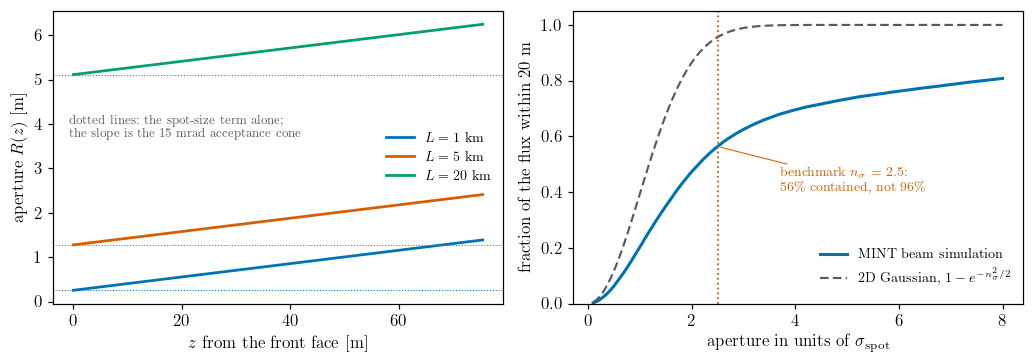

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))

z = np.linspace(0, det.Z_MUON1, 400)
for D, c, ls in [(1e5, "#0072B2", "-"), (5e5, "#D55E00", "-"), (20e5, "#009E73", "-")]:
    dd = mint.detectors.load("benchmark_5km", dist=D)
    ax[0].plot(z/100, dd.aperture(z)/100, color=c, ls=ls, lw=1.8,
               label=rf"$L = {D/1e5:.0f}$ km")
    ax[0].axhline(dd.n_sigma*dd.sigma_spot/100, color=c, lw=0.7, ls=":")
ax[0].set_xlabel(r"$z$ from the front face [m]")
ax[0].set_ylabel(r"aperture $R(z)$ [m]")
ax[0].legend(frameon=False, fontsize=9)
ax[0].annotate("dotted lines: the spot-size term alone;\n"
               "the slope is the 15 mrad acceptance cone",
               xy=(0.035, 0.60), xycoords="axes fraction", fontsize=8,
               color="0.35", va="center")

# measured containment vs the Gaussian the design assumes
ns_grid = np.linspace(0.1, 8.0, 120)
meas = np.array([w_all[r_face < n*det.sigma_spot].sum()/w_all.sum() for n in ns_grid])
ax[1].plot(ns_grid, meas, color="#0072B2", lw=2.0, label="MINT beam simulation")
ax[1].plot(ns_grid, 1-np.exp(-ns_grid**2/2), color="0.35", lw=1.4, ls=(0, (4, 2)),
           label=r"2D Gaussian, $1-e^{-n_\sigma^2/2}$")
ax[1].axvline(det.n_sigma, color="#D55E00", lw=1.2, ls=":")
ax[1].annotate(rf"benchmark $n_\sigma = {det.n_sigma}$:" "\n"
               rf"{frac*100:.0f}\% contained, not 96\%",
               xy=(det.n_sigma, frac), xytext=(0.46, 0.42),
               textcoords="axes fraction", fontsize=8.5, color="#D55E00",
               ha="left", va="center", clip_on=False,
               arrowprops=dict(arrowstyle="-", lw=0.7, color="#D55E00"))
ax[1].set_xlabel(r"aperture in units of $\sigma_{\rm spot}$")
ax[1].set_ylabel(rf"fraction of the flux within {R_MAX/100:.0f} m")
ax[1].set_ylim(0, 1.05)
ax[1].legend(frameon=False, fontsize=9, loc="lower right",
             bbox_to_anchor=(1.0, 0.02))
fig.tight_layout()
fig.savefig("plots/benchmark_detector_aperture.pdf", bbox_inches="tight", dpi=300)

## 2. Layout and composition

The stack, with $z$ measured from the front face:

| $z$ [m] | module | half-width | material |
|---|---|---|---|
| 0.0 | halo tagger | fixed 2 m | 0.4 g/cm$^2$ tracking, full face |
| 2.0 – 3.2 | **vertex tracker** | $\min(R,\,0.5\ {\rm m})$ | 24 plates (2 mm graphite + 150 $\mu$m Si) on a 5 cm pitch |
| 3.2 – 12.0 | drift | $R(z)$ | air (lever arm) |
| 12.0 – 51.5 | TPC core | $R(z)$ | 4 $\times$ 9.5 m of 5 bar argon, 0.5 m gaps |
| (in the gaps) | vessel walls | $R(z)$ | 0.20 $X_0$ carbon composite each |
| 52.0 | end cap | $R(z)$ | 0.30 $X_0$ carbon composite |
| 52.5 – 55.5 | calorimeter | $\max(R,3\,{\rm m})$ | 32 $X_0$ W/Si + 10 $\lambda_I$ Fe/scint |
| 55.5 – 75.5 | muon spectrometer | $\max(R,3\,{\rm m})$ | air-core dipole |

**The vertex tracker exists for charm, and nothing else.** $D^0$ and $D^\pm$
have $\gamma c\tau$ of order 1–15 cm over this energy range, so resolving their
decay needs a few-cm sampling pitch and a small impact parameter. It does *not*
need target mass -- the 38 m of gas supplies that far more cheaply -- so the
slab is kept thin (11 g/cm$^2$, 0.29 $X_0$) and, more importantly, **narrow**.

Silicon area is the cost driver. Instrumenting the full acceptance cone with 24
planes would take of order $10^3$ m$^2$, more than any tracker ever built;
capping the half-width at 0.5 m brings that to $\sim$19 m$^2$. The flux is
enormous, so a tracker that sees only the beam core still collects a large charm
sample, and every other process is left to the gas.

It is modelled as **one homogenised slab** -- the graphite plates and their
silicon sensors smeared over the plate pitch -- rather than 24 discrete
cassettes. That reproduces the column, $X_0$ and $\lambda_I$ exactly and places
interaction vertices uniformly along $z$, which is all a rate calculation can
use. It also cuts the detector from $\sim$212 ray-traced volumes to 13.

**Why graphite and not tungsten.** At a fixed radiation-length budget graphite
gives 21.4 g/cm$^2$ of target against tungsten's 3.4 -- a factor 6.3 in mass --
while tungsten buys only $\sim$1.6$\times$ in electromagnetically-coherent
yield, because the mass penalty nearly cancels the $Z^2/A$ gain. High-$Z$ is not
the automatic choice. (That comparison is specific to a mediator coupling to the
electromagnetic current; a $B-L$ or baryonic mediator scales as $A^2$, and an
incoherent process as $A$.) Override ``foil_mat`` to compare.

In [6]:
rows = det.column_table()
print(f"{'group':20s}{'z0 [m]':>8s}{'z1 [m]':>8s}{'material':>10s}"
      f"{'column':>11s}{'X0':>9s}{'lambda_I':>10s}")
print(f"{'':20s}{'':8s}{'':8s}{'[cm]':>10s}{'[g/cm2]':>11s}")
for r in rows:
    print(f"{r['group']:20s}{r['z0 [m]']:8.1f}{r['z1 [m]']:8.1f}"
          f"{r['material [cm]']:10.2f}{r['column [g/cm2]']:11.2f}"
          f"{r['X0']:9.3f}{r['lambda_I']:10.3f}")

trk = mint.detectors.TRACKING_KINDS
print(f"\ntracking region (everything upstream of the calorimeter):")
print(f"   column   = {det.column(kinds=trk):8.1f} g/cm^2")
print(f"   X0       = {det.radiation_lengths(kinds=trk):8.2f}")
print(f"   lambda_I = {det.interaction_lengths(kinds=trk):8.3f}")
print(f"   nucleons = {det.nucleon_column():.4e} /cm^2")
print(f"   electrons= {det.electron_column():.4e} /cm^2")

group                 z0 [m]  z1 [m]  material     column       X0  lambda_I
                                          [cm]    [g/cm2]
halo tagger              0.0    10.9      0.50       0.68    0.022     0.007
vertex tracker           2.0     3.2    120.00      11.45    0.287     0.131
TPC gas                 12.0    51.5   3800.00      31.58    1.615     0.269
TPC structure           21.7    52.0     17.39      38.43    0.900     0.448
calorimeter             52.5    55.3    277.20    1631.85  129.784    12.263
muon spectrometer       55.5    75.5   2000.00       2.45    0.067     0.027

tracking region (everything upstream of the calorimeter):
   column   =     82.1 g/cm^2
   X0       =     2.82
   lambda_I =    0.856
   nucleons = 2.5926e+25 /cm^2
   electrons= 1.2011e+25 /cm^2


### The layout figure

NOTE: elements thinner than 40 cm are drawn at that width so they stay visible on a 75 m axis -- the halo monitor (0.38 cm), the TPC vessel walls (3.9 cm) and the end cap (5.8 cm). Their z positions, and every column density in this notebook, are exact.


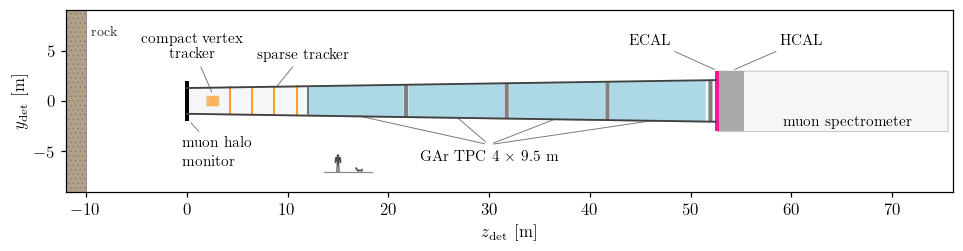

In [7]:
# Material -> (colour, label).
MAT_STYLE = [
    (det.gas,        "lightblue", r"5 bar Ar (TPC gas)"),
    (det.vertex_mat, "darkorange",    r"vertex tracker (graphite + Si)"),
    (det.vessel_mat, "grey",    r"graphite (TPC vessel walls)"),
    (det.halo_mat,   "black",      r"halo monitor"),
    (det.ecal_mat,   "deeppink",    r"W/Si (ECAL)"),
    (det.hcal_mat,   "darkgrey",    r"Fe/scint (HCAL)"),
]
COLOR = {id(m): c for m, c, _ in MAT_STYLE}
ENVELOPE = "#f4f6f8"
MIN_DRAW_CM = 40.0       # thin planes get widened to stay visible on a 75 m axis


def draw_stack(ax, dd, z_lo, z_hi, envelope=True):
    # Detector cross-section in (z, +/-r), both halves, metres.
    if envelope:
        zz = np.linspace(z_lo, z_hi, 400)
        rr = np.array([max(dd.aperture(z), dd.CALO_R_FLOOR)
                       if z >= dd.Z_CALO0 else dd.aperture(z) for z in zz])
        ax.fill_between(zz/100, -rr/100, rr/100, color=ENVELOPE,
                        edgecolor="0.75", lw=0.6, zorder=1)
    for m in dd.modules:
        if m.z1 < z_lo or m.z0 > z_hi or m.kind == "air":
            continue
        if m.name == "vertex tracker" or m.name.startswith("sparse"):
            continue          # drawn plane-by-plane below
        for (a, b, r0, r1) in dd._segments(m):
            if b - a < MIN_DRAW_CM:          # widen about the centre, keep z
                c = 0.5*(a + b)
                a, b = c - MIN_DRAW_CM/2, c + MIN_DRAW_CM/2
            xy = np.array([[a/100, r0/100], [b/100, r1/100],
                           [b/100, -r1/100], [a/100, -r0/100]])
            ax.add_patch(Polygon(xy, closed=True, facecolor=COLOR[id(m.material)],
                                 edgecolor="none", zorder=3))
    zz = np.linspace(z_lo, 5250, 300)
    for sgn in (+1, -1):
        ax.plot(zz/100, sgn*dd.aperture(zz)/100, color="0.25", lw=1.2, ls="-",
                zorder=5)


fig, ax = plt.subplots(figsize=(10.4, 3.9))
draw_stack(ax, det, 0.0, det.Z_MUON1)

ax.set_xlim(-det.gap / 100.0 - 2.0, 76)   # left edge = start of the rock
ax.set_ylim(-9, 9)
ax.set_xlabel(r"$z_{\rm det}$ [m]")
ax.set_ylabel(r"$y_{\rm det}$ [m]")

# ---------------------------------------------------------------------------
# upstream context: the last 2 m of the rock, then the air gap to the face
# ---------------------------------------------------------------------------
from matplotlib.patches import Rectangle, Circle, Ellipse

ROCK_C, Y_LIM = "#b2a189", 20.0        # taller than any ylim; axes clip it
z_rock1 = -det.gap / 100.0                    # rock ends where the gap starts
z_rock0 = z_rock1 - 2.0                       # show 2 m of it
ax.add_patch(Rectangle((z_rock0, -Y_LIM), 2.0, 2 * Y_LIM, facecolor=ROCK_C,
                       edgecolor="none", zorder=2))
ax.add_patch(Rectangle((z_rock0, -Y_LIM), 2.0, 2 * Y_LIM, facecolor="none",
                       edgecolor="0.45", lw=0.5, hatch="....", zorder=2))
ax.annotate("rock", xy=(z_rock1 + 0.5, 6.9), fontsize=9, color="0.15",
            ha="left", va="center")


# ---------------------------------------------------------------------------
# scale figures, drawn at true size on the equal-aspect axes
# ---------------------------------------------------------------------------
def draw_person(ax, x, y_feet, h=1.8, color="0.30", zorder=7):
    """A 1.8 m standing silhouette; coordinates are fractions of the height."""
    body = np.array([
        (-0.09, 0.855), (-0.165, 0.83), (-0.185, 0.52), (-0.125, 0.505),
        (-0.075, 0.625), (-0.075, 0.45), (-0.095, 0.015), (-0.025, 0.015),
        (-0.012, 0.42), (0.012, 0.42), (0.025, 0.015), (0.095, 0.015),
        (0.075, 0.45), (0.075, 0.625), (0.125, 0.505), (0.185, 0.52),
        (0.165, 0.83), (0.09, 0.855)])
    ax.add_patch(Polygon(np.column_stack([x + body[:, 0] * h,
                                          y_feet + body[:, 1] * h]),
                         closed=True, facecolor=color, edgecolor="none",
                         zorder=zorder))
    ax.add_patch(Circle((x, y_feet + 0.925 * h), 0.078 * h, facecolor=color,
                        edgecolor="none", zorder=zorder))


# Side-view cat as ONE closed outline: body, head, ears and all four legs are
# a single path, so nothing detaches and no notches open up when it is drawn
# only a few pixels tall. Coordinates are (length, height) fractions, nose
# first. (The previous version drew separate ellipses and rectangles, which at
# this scale read as two blobs rather than a cat.)
_CAT_OUTLINE = [
    (0.00, 0.60), (0.03, 0.71), (0.06, 0.76),          # nose, forehead
    (0.07, 1.00), (0.13, 0.80),                        # near ear
    (0.19, 0.81), (0.25, 0.99), (0.28, 0.78),          # far ear
    (0.32, 0.71), (0.39, 0.65),                        # back of head, neck
    (0.55, 0.67), (0.75, 0.69), (0.88, 0.65),          # back
    (0.96, 0.55), (0.98, 0.40), (0.94, 0.29),          # rump, haunch
    (0.95, 0.00), (0.89, 0.00), (0.90, 0.27),          # hind leg, far
    (0.80, 0.29), (0.79, 0.00), (0.73, 0.00),          # hind leg, near
    (0.74, 0.29), (0.41, 0.29),                        # belly
    (0.40, 0.00), (0.34, 0.00), (0.35, 0.29),          # fore leg, far
    (0.28, 0.29), (0.27, 0.00), (0.21, 0.00),          # fore leg, near
    (0.22, 0.33), (0.14, 0.41), (0.05, 0.51),          # chest, chin
]


def draw_cat(ax, x, y_feet, h=0.30, color="0.30", zorder=7, facing=-1, lw=1.2):
    """A cat in side view, ``h`` tall to the ear tips and 1.55 h long.
    ``facing`` = -1 puts the nose to the left, +1 to the right."""
    L = 1.55 * h

    def P(u, v):
        return (x + (u if facing > 0 else (1.0 - u)) * L, y_feet + v * h)

    ax.add_patch(Polygon([P(u, v) for u, v in _CAT_OUTLINE], closed=True,
                         facecolor=color, edgecolor="none", zorder=zorder))
    s = np.linspace(0.0, 1.0, 50)                       # tail, off the rump
    ax.plot(*zip(*[P(0.94 + 0.20 * np.sin(1.7 * t), 0.55 + 0.52 * t ** 0.8)
                   for t in s]),
            color=color, lw=lw, solid_capstyle="round", zorder=zorder)


# the two tracker stations, drawn as their individual planes
VTX_C, SPARSE_C = COLOR[id(det.vertex_mat)], "darkorange"
r_vtx = det.vertex_radius / 100.0
# NOTE 24 planes on a 5 cm pitch span 1.2 m, which on an 88 m frame is a
# 0.42 pt gap between them -- thinner than any sensible line. They are
# drawn as 24 separate strokes and resolve when the vector PDF is zoomed,
# but at normal size they necessarily merge into a bar. That is what a
# 5 cm-pitch stack actually looks like at this scale.
for z in np.linspace(det.Z_VTX0, det.Z_VTX1, det.n_plates, endpoint=False):
    ax.plot([z / 100.0] * 2, [-r_vtx, r_vtx], color=VTX_C, lw=0.28, zorder=4)
for m in det.modules:
    if not m.name.startswith("sparse"):
        continue
    zc = 0.5 * (m.z0 + m.z1)
    rr = det.aperture(zc) / 100.0
    ax.plot([zc / 100.0] * 2, [-rr, rr], color=SPARSE_C, lw=1.1, zorder=4)

Y_FLOOR = -7.1                                 # empty band below the TPC
draw_person(ax, 15.0, Y_FLOOR)
draw_cat(ax, 16.9, Y_FLOOR, h=0.40)   # ~0.4 m to the ear tips
ax.plot([13.6, 18.4], [Y_FLOOR, Y_FLOOR], color="0.55", lw=0.8, zorder=6)
# ax.annotate("", xy=(13.2, Y_FLOOR), xytext=(13.2, Y_FLOOR + 1.8),
            # arrowprops=dict(arrowstyle="<->", lw=0.7, color="0.45"))
# ax.annotate("1.8 m", xy=(12.9, Y_FLOOR + 0.9), fontsize=8, color="0.35",
            # ha="right", va="center")

LAB = [(r"\noindent muon halo\\ monitor",      3.0, -5.0,  0.2, -1.95, "center"),
       ("compact vertex\ntracker",             0.5,  5.4,  2.6,  0.60, "center"),
       ("sparse tracker",                     11.5,  4.6,  8.7,  1.15, "center"),
       ("ECAL",                               46.0,  6.0, 52.63, 3.00, "center"),
       ("HCAL",                               61.0,  6.0, 54.10, 3.00, "center"),
       ]
for text, xt, yt, xa, ya, ha in LAB:
    ax.annotate(text, xy=(xa, ya), xytext=(xt, yt), fontsize=10, color='black',
                ha=ha, va="center",
                arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45",
                                shrinkA=2, shrinkB=2))

# one label for the four gas modules, with the leaders fanning out of a single
# point so it is clear the caption covers all of them
fan = (30.0, -4.35)
for za, zb in det._tpc_module_edges():
    zc = 0.5 * (za + zb) / 100
    ax.annotate("", xy=(zc, -det.aperture(zc*100)/100 + 0.10), xytext=fan,
                arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45",
                                shrinkA=3, shrinkB=2))
ax.text(fan[0], -5.5, r"GAr TPC 4 $\times$ 9.5 m", fontsize=10, color="black",
        ha="center", va="center")

ax.annotate("muon spectrometer", xy=(65.5, -2.5), xytext=(65.5, -2), fontsize=10,
            color='black', ha="center", va="center")

# boundary between the upstream tracking region and the gas TPC
z_div = det.Z_TPC0 / 100
r_div = det.aperture(det.Z_TPC0) / 100
ax.plot([z_div, z_div], [-r_div, r_div], color="0.35", lw=1.0, ls=(0, (3, 0)),
        zorder=6)
# ax.annotate("tracker", xy=(z_div - 0.7, 2.35), fontsize=9, color="0.35",
#             ha="right", va="center")
# ax.annotate("gas TPC", xy=(z_div + 0.7, 2.35), fontsize=9, color="0.35",
#             ha="left", va="center")

ax.set_aspect("equal", adjustable="box")
handles = [Patch(facecolor=c, edgecolor="none", label=lab)
           for m, c, lab in MAT_STYLE]
handles += [Patch(facecolor=ENVELOPE, edgecolor="0.75", lw=0.6,
                  label="instrumented aperture (air)"),
            Line2D([0], [0], color="0.25", lw=1.2, label=r"aperture $R(z)$")]
fig.savefig("plots/benchmark_detector_layout.png", bbox_inches="tight", dpi=500)

print(f"NOTE: elements thinner than {MIN_DRAW_CM:.0f} cm are drawn at that width so "
      "they stay visible on a 75 m axis -- the halo monitor (0.38 cm), the TPC "
      "vessel walls (3.9 cm) and the end cap (5.8 cm). Their z positions, and "
      "every column density in this notebook, are exact.")


## 3. Material budget along the axis

Where the material actually sits. Column density and radiation/interaction
lengths are plotted in **separate panels** rather than on twin axes -- they are
different quantities and a shared frame with two scales would invite reading a
crossing point that means nothing.

The step at $z = 52.5$ m is the whole point of the redesign: the tracking region
carries 95 g/cm$^2$ and 1.5 $X_0$, and everything heavy is behind it.

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_75014/1252307177.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


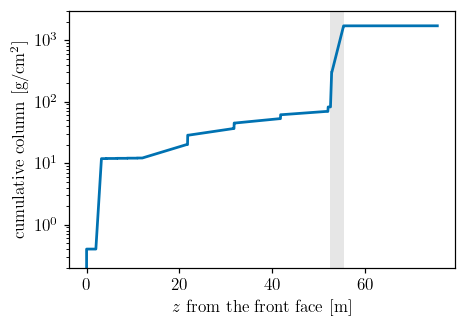

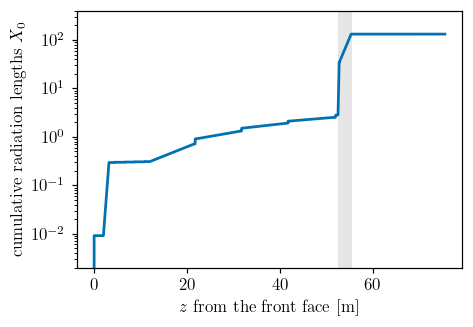

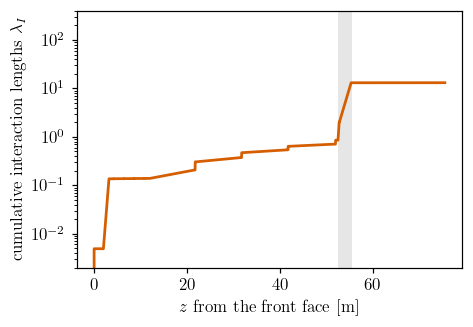

In [11]:


def cumulative(dd, kinds=None, quantity="column"):
    # cumulative material along the axis, as a step function of z
    edges, vals = [0.0], [0.0]
    mods = sorted(
        [m for m in dd.modules if kinds is None or m.kind in kinds],
        key=lambda m: m.z0,
    )
    acc = 0.0

    for m in mods:
        if quantity == "column":
            step = m.material.density * m.thickness
        elif quantity == "X0":
            step = (
                m.material.density
                * m.thickness
                / dt.radiation_length(m.material)
            )
        elif quantity == "lambda":
            step = (
                m.material.density
                * m.thickness
                / dt.interaction_length(m.material)
            )
        else:
            raise ValueError(f"unknown quantity: {quantity}")

        edges += [m.z0, m.z1]
        vals += [acc, acc + step]
        acc += step

    edges += [dd.Z_MUON1]
    vals += [acc]
    return np.array(edges) / 100, np.array(vals)



figs = []
ax = []
for i in range(3):
    fig, a = mint.plot_tools.std_fig()
    figs.append(fig)
    ax.append(a)

zc, cc = cumulative(det, quantity="column")
ax[0].plot(zc, cc, color="#0072B2", lw=1.8)
ax[0].set_yscale("log")
ax[0].set_ylim(0.2, 3e3)
ax[0].set_xlabel(r"$z$ from the front face [m]")
ax[0].set_ylabel(r"cumulative column [g/cm$^2$]")

zc, cc = cumulative(det, quantity="X0")
ax[1].plot(zc, cc, color="#0072B2", lw=1.8)
ax[1].set_yscale("log")
ax[1].set_ylim(2e-3, 4e2)
ax[1].set_xlabel(r"$z$ from the front face [m]")
ax[1].set_ylabel(r"cumulative radiation lengths $X_0$")

zc, cc = cumulative(det, quantity="lambda")
ax[2].plot(zc, cc, color="#D55E00", lw=1.8)
ax[2].set_yscale("log")
ax[2].set_ylim(2e-3, 4e2)
ax[2].set_xlabel(r"$z$ from the front face [m]")
ax[2].set_ylabel(r"cumulative interaction lengths $\lambda_I$")

for a in ax:
    a.axvspan(52.5, 55.5, color="0.9", zorder=0, lw=0)

fig.tight_layout()
fig.savefig("plots/benchmark_detector_budget.pdf", bbox_inches="tight", dpi=300)

## 4. What the material budget means for rates

The detector is deliberately light: a long, low-density gas volume rather than a
short dense one. That trades interaction rate for a large decay volume, which is
what makes it sensitive to long-lived states produced upstream.


In [12]:
# neutrino interaction rate through the new geometry
E, w, chord = det.flux_with_chords(sim, exposure=ipy, kinds=("gas",))
sig = mint.xsecs.total_xsecs[sim.nuflavor](E)
n_gas = (w * sig * det.gas.N * chord).sum()
print(f"{sim.nuflavor} interactions in the TPC gas: {n_gas:.3e} / year")

E2, w2, ch2 = det.flux_with_chords(sim, exposure=ipy, kinds=("vertex",))
sig2 = mint.xsecs.total_xsecs[sim.nuflavor](E2)
print(f"{sim.nuflavor} interactions in the vertex tracker: "
      f"{(w2*sig2*det.vertex_mat.N*ch2).sum():.3e} / year")

# the whole-detector total has to be summed per volume, because each one
# carries its own nucleon density
rays = dt.sim_rays(sim)
E_all_r = np.asarray(sim.pnu["E"])
w_all_r = sim.weights.flatten() * ipy
sig_all = mint.xsecs.total_xsecs[sim.nuflavor](E_all_r)
tot = 0.0
for kinds, lab in [(("tracker",), "halo tagger"), (("vertex",), "vertex tracker"),
                   (("gas",), "argon gas"), (("structure",), "TPC vessel"),
                   (("absorber",), "calorimeter"),
                   (("air",), "spectrometer air")]:
    r = 0.0
    for v in det.volumes(kinds=kinds):
        _, c = v.intersect(*rays)
        r += float((w_all_r * sig_all * v.material.N * c).sum())
    tot += r
    print(f"   {lab:18s} {r:.3e} /yr")
print(f"   {'TOTAL':18s} {tot:.3e} /yr")

numubar interactions in the TPC gas: 3.554e+08 / year
numubar interactions in the vertex tracker: 4.015e+07 / year
   halo tagger        7.555e+06 /yr
   vertex tracker     4.015e+07 /yr
   argon gas          3.554e+08 /yr
   TPC vessel         4.401e+08 /yr
   calorimeter        2.112e+10 /yr
   spectrometer air   3.161e+07 /yr
   TOTAL              2.200e+10 /yr


## 5. Assumptions and caveats

**Stated in the design:** 
* the aperture formula and its two
parameters; 
* the module boundaries; 
* the cassette segmentation (100 on a 10 cm pitch); 
* 5 bar argon over 38 m; 
* the ECAL and HCAL layer recipes, reproducing 32 $X_0$ and 10 $\lambda_I$ exactly.

**Assumed:**

* The TPC pressure-vessel walls (0.20 $X_0$ each) and end cap (0.30 $X_0$) are
  taken to be **carbon composite**. The design specifies only the radiation
  length, but it also quotes 0.15 $\lambda_I$ for the end cap, and
  $\lambda_I/X_0$ for carbon reproduces that at 0.149 -- aluminium would give
  0.067. So carbon is what the numbers imply, not a free choice.
* The halo tagger's 0.4 g/cm$^2$ is modelled as plastic. Its column matches the
  design exactly, but its 0.009 $X_0$ falls short of the quoted 0.02, so the
  design's tagger must contain some silicon or support structure. Only the
  column enters a rate, so this does not propagate.
* The calorimeter is **homogenised** into two mixtures rather than 40 + 84
  discrete layers. MINT never resolves shower structure, and the mixture
  reproduces the column, $X_0$ and $\lambda_I$ exactly.

**Note on the aperture.** `sigma_div` defaults to the design's 0.1 mrad.

## 6. The shielding geometry

Per-segment aperture $=5\,\max(\sigma_x,\sigma_y)$ from the packaged 10 TeV
lattice, floored at 2 cm. The chicane is located automatically from the
closed-orbit excursion and given the thicker dipole wall.

  k   z0[m]   z1[m]  r_in[cm]  wall[cm]  r_out[cm]
  0     6.0    10.8      3.66      2.53       6.19
  3    20.5    25.3     10.26      2.53      12.79
  6    35.0    39.8      8.51      2.53      11.04
  9    49.5    54.3      7.83      4.50      12.33
 12    64.0    68.8      6.59      2.53       9.12
 15    78.5    83.3      5.35      2.53       7.88
 18    93.0    97.8      4.11      2.53       6.64
 21   107.5   112.3      2.91      2.53       5.44
 24   122.0   126.8      2.32      2.53       4.85
 27   136.5   141.3      2.00      2.53       4.53
 30   151.0   155.8      2.00      2.53       4.53
 33   165.5   170.3      2.20      2.53       4.73

chicane span (auto-detected): [44.66666667 64.        ] m
aperture range: 2.00 - 10.26 cm
MuCol Table 2 inner COIL radii for the IR magnets: 7 - 16 cm (ours is the vacuum bore + wall = 4.5 - 12.8 cm)


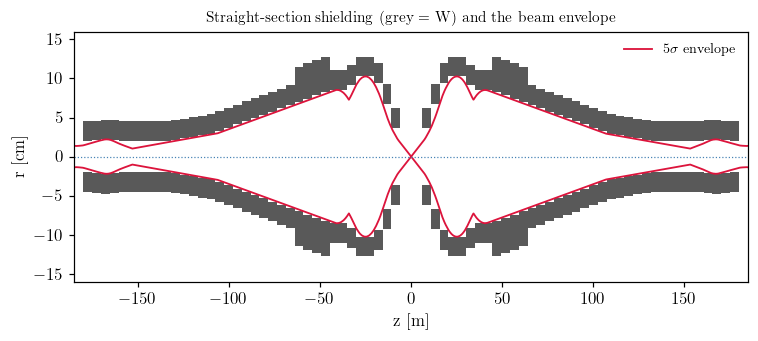

In [14]:
sh = bl.shield
print(f"{'k':>3} {'z0[m]':>7} {'z1[m]':>7} {'r_in[cm]':>9} {'wall[cm]':>9} {'r_out[cm]':>10}")
for k in range(0, len(sh.r_in), 3):
    print(f"{k:3d} {sh.edges[k]/100:7.1f} {sh.edges[k+1]/100:7.1f} "
          f"{sh.r_in[k]:9.2f} {sh.t_wall[k]:9.2f} {sh.r_out[k]:10.2f}")
print(f"\nchicane span (auto-detected): {np.array(sh.chicane_span)/100} m")
print(f"aperture range: {sh.r_in.min():.2f} - {sh.r_in.max():.2f} cm")
print(f"MuCol Table 2 inner COIL radii for the IR magnets: 7 - 16 cm "
      f"(ours is the vacuum bore + wall = {sh.r_out.min():.1f} - {sh.r_out.max():.1f} cm)")

fig, ax = plt.subplots(figsize=(7, 3.2))
for k in range(len(sh.r_in)):
    z0, z1 = sh.edges[k]/100, sh.edges[k+1]/100
    for s in (+1, -1):
        ax.add_patch(Rectangle((s*z0 if s > 0 else -z1, sh.r_in[k]), z1-z0,
                               sh.t_wall[k], facecolor="0.35", edgecolor="none"))
        ax.add_patch(Rectangle((s*z0 if s > 0 else -z1, -sh.r_out[k]), z1-z0,
                               sh.t_wall[k], facecolor="0.35", edgecolor="none"))
u = np.linspace(0, 1, 40001)
s_ = np.asarray(ring.s(u)); x_ = np.asarray(ring.x(u)); y_ = np.asarray(ring.y(u))
z_ = np.asarray(ring.z(u))
i0 = int(np.argmin(x_**2 + y_**2 + z_**2)); dz = (s_ - s_[i0])/100
env = 5*np.maximum(ring.beamsize_x(u), ring.beamsize_y(u))
m = np.abs(dz) <= 185
ax.plot(dz[m], env[m], color="crimson", lw=1.2, label=r"$5\sigma$ envelope")
ax.plot(dz[m], -env[m], color="crimson", lw=1.2)
ax.axhline(0, color="steelblue", lw=0.8, ls=":")
ax.set_xlim(-185, 185); ax.set_ylim(-16, 16)
ax.set_xlabel("z [m]"); ax.set_ylabel("r [cm]")
ax.set_title("Straight-section shielding (grey = W) and the beam envelope", fontsize=10)
ax.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout()

## 7. Density map of the whole problem

`Beamline.density_map` on a $(z, r)$ grid. Note the log $z$ axis: the
straight section, the rock and the detector differ by three orders of
magnitude in scale.

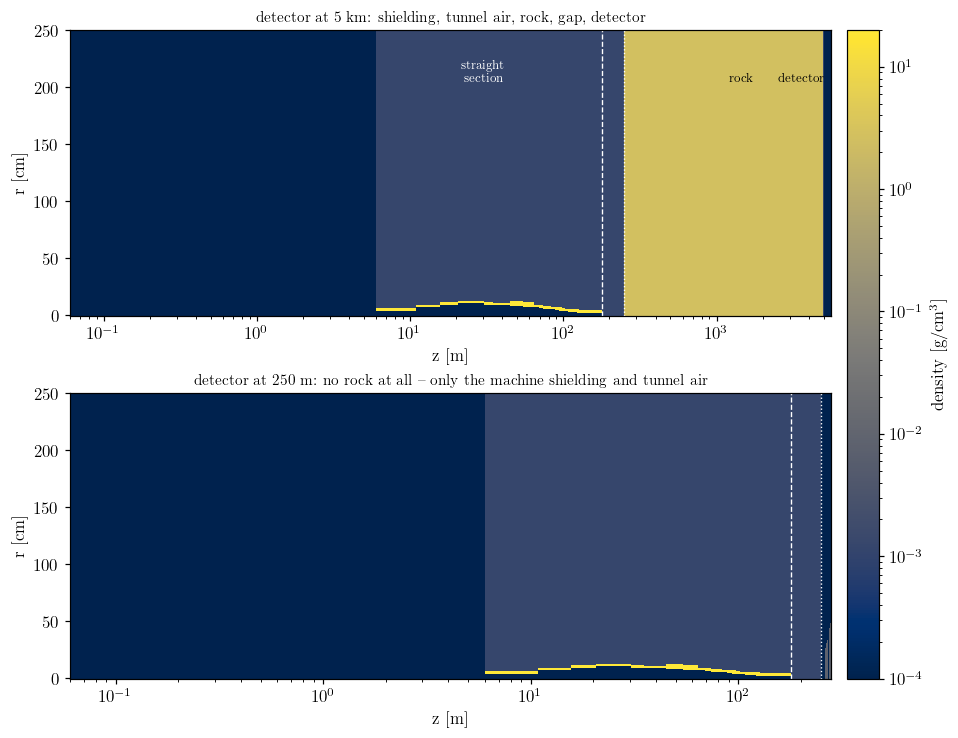

In [15]:
def draw_density(dist, ax, zlim=None, rlim=60.0, nz=1400, nr=420, log_z=True):
    z_hi = zlim if zlim is not None else dist + det.length*1.4
    zg = (np.geomspace(6.0, z_hi, nz) if log_z else np.linspace(0.0, z_hi, nz))
    rg = np.linspace(0.0, rlim, nr)
    rho = bl.density_map(zg, rg, dist=dist)
    pc = ax.pcolormesh(zg/100, rg, np.maximum(rho, 1e-5), shading="auto",
                       norm=LogNorm(vmin=1e-4, vmax=20.0), cmap="cividis")
    if log_z: ax.set_xscale("log")
    ax.set_xlabel("z [m]"); ax.set_ylabel("r [cm]")
    return pc

fig, axes = plt.subplots(2, 1, figsize=(8.6, 6.6), constrained_layout=True)
pc = draw_density(5e5, axes[0], zlim=5.6e5, rlim=250)
axes[0].set_title("detector at 5 km: shielding, tunnel air, rock, gap, detector",
                  fontsize=10)
pc = draw_density(250e2, axes[1], zlim=2.8e4, rlim=250)
axes[1].set_title("detector at 250 m: no rock at all -- only the machine "
                  "shielding and tunnel air", fontsize=10)
for ax in axes:
    ax.axvline(bl.straight_half_length/100, color="w", lw=0.9, ls="--")
    ax.axvline(det.rock_start/100, color="w", lw=0.9, ls=":")
axes[0].annotate("straight\nsection", xy=(30, 205), color="w", fontsize=8, ha="center")
axes[0].annotate("rock", xy=(1200, 205), color="k", fontsize=8)
axes[0].annotate("detector", xy=(5000, 205), color="k", fontsize=8, ha="right")
fig.colorbar(pc, ax=axes, label=r"density [g/cm$^3$]", pad=0.02)
fig.savefig("plots/beamline_density_map.pdf", bbox_inches="tight", dpi=300)

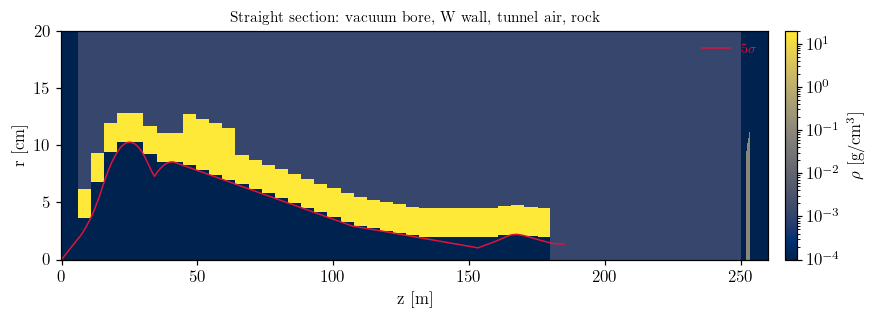

In [12]:
# zoom on the straight section: the tungsten tube and its tapering bore
fig, ax = plt.subplots(figsize=(8.5, 3.0))
zg = np.linspace(0.0, 260e2, 1600); rg = np.linspace(0.0, 20.0, 400)
rho = bl.density_map(zg, rg, dist=250e2)
pc = ax.pcolormesh(zg/100, rg, np.maximum(rho, 1e-5), shading="auto",
                   norm=LogNorm(vmin=1e-4, vmax=20.0), cmap="cividis")
ax.plot(dz[m][dz[m] >= 0], env[m][dz[m] >= 0], color="crimson", lw=1.0,
        label=r"$5\sigma$")
ax.set_xlabel("z [m]"); ax.set_ylabel("r [cm]"); ax.set_ylim(0, 20)
ax.legend(frameon=False, fontsize=9, loc="upper right", labelcolor="crimson")
ax.set_title("Straight section: vacuum bore, W wall, tunnel air, rock", fontsize=10)
fig.colorbar(pc, ax=ax, label=r"$\rho$ [g/cm$^3$]", pad=0.02)
plt.tight_layout()

## 8. Validation of the tube geometry

Analytic closure of `TubeVolume`, convergence in the number of segments, and
the sensitivity to the two assumptions (drift-section wall thickness and the
minimum aperture).

In [16]:
tube = dt.TubeVolume(dt.W, r_in=2.0, r_out=4.0, length=100.0, center=(0,0,50.0))
o = np.array([[0.],[0.],[0.]])
checks = [
  ("axial down the bore",        np.array([[0.],[0.],[1.]]), o,                       0.0),
  ("axial inside the wall",      np.array([[0.],[0.],[1.]]), np.array([[3.],[0.],[0.]]), 100.0),
  ("transverse through centre",  np.array([[1.],[0.],[0.]]), np.array([[-10.],[0.],[50.]]), 4.0),
  ("transverse miss (r>r_out)",  np.array([[1.],[0.],[0.]]), np.array([[-10.],[5.],[50.]]), 0.0),
  ("transverse at b=3",          np.array([[1.],[0.],[0.]]), np.array([[-10.],[3.],[50.]]), 2*np.sqrt(7)),
]
print(f"{'case':28s} {'chord':>10} {'expected':>10}   ok")
for name, d, oo, exp in checks:
    got = float(tube.intersect(oo, d)[1][0])
    print(f"{name:28s} {got:10.5f} {exp:10.5f}   {np.isclose(got, exp)}")
th_ = 0.05
got = float(tube.intersect(o, np.array([[np.sin(th_)],[0.],[np.cos(th_)]]))[1][0])
print(f"{'small-angle from origin':28s} {got:10.5f} {(4-2)/np.sin(th_):10.5f}   "
      f"{np.isclose(got, (4-2)/np.sin(th_))}")

case                              chord   expected   ok
axial down the bore             0.00000    0.00000   True
axial inside the wall         100.00000  100.00000   True
transverse through centre       4.00000    4.00000   True
transverse miss (r>r_out)       0.00000    0.00000   True
transverse at b=3               5.29150    5.29150   True
small-angle from origin        40.01667   40.01667   True


In [17]:
ths = np.array([1e-4, 2e-4, 4e-4, 8e-4])
o0 = np.zeros((3, ths.size)); d0 = np.array([np.sin(ths), np.zeros_like(ths), np.cos(ths)])
print("W path [m] for a ray leaving the IP -- convergence in segmentation")
print("  nseg |" + "".join(f"{t*1e6:9.0f} ur" for t in ths))
for n in (9, 18, 36, 72, 144, 288):
    s_ = mint.beamline.StraightSectionShield(lattice=ring, n_segments=n)
    print(f"  {n:4d} |" + "".join(f"{c/100:12.2f}" for c in s_.chord(o0, d0)))

print("\nsensitivity to the two ASSUMPTIONS")
print("  min aperture [cm] |" + "".join(f"{t*1e6:9.0f} ur" for t in ths))
for rmin in (1.0, 2.0, 3.0, 5.0):
    s_ = mint.beamline.StraightSectionShield(lattice=ring, min_aperture=rmin)
    print(f"  {rmin:17.1f} |" + "".join(f"{c/100:12.2f}" for c in s_.chord(o0, d0)))
print("  drift wall [cm]   |" + "".join(f"{t*1e6:9.0f} ur" for t in ths))
for tw in (1.0, 2.53, 4.5):
    s_ = mint.beamline.StraightSectionShield(lattice=ring, thickness=tw)
    print(f"  {tw:17.2f} |" + "".join(f"{c/100:12.2f}" for c in s_.chord(o0, d0)))

W path [m] for a ray leaving the IP -- convergence in segmentation
  nseg |      100 ur      200 ur      400 ur      800 ur
     9 |        0.00       58.00       19.33       10.99
    18 |        0.00       58.00       19.33       19.33
    36 |        0.00       58.00       24.17       14.54
    72 |        0.00       59.09       24.31       14.54
   144 |        0.00       59.21       25.38       14.86
   288 |        0.00       59.81       25.44       15.14

sensitivity to the two ASSUMPTIONS
  min aperture [cm] |      100 ur      200 ur      400 ur      800 ur
                1.0 |       14.24       58.00       24.17       14.54
                2.0 |        0.00       58.00       24.17       14.54
                3.0 |        0.00       30.00       40.42       14.54
                5.0 |        0.00        0.00       55.00       20.46
  drift wall [cm]   |      100 ur      200 ur      400 ur      800 ur
               1.00 |        0.00       28.00        9.38        5.73
        

## 9. The beam simulation, with the $5\sigma$ collimation

`MuDecaySimulator` truncates the transverse beam envelope at the physical
aperture (`aperture_nsigma=5`), namely, a 2D Gaussian truncated at $5\sigma$ keeps $1-e^{-25/2} = 1 - 3.7\times10^{-6}$ of the beam.

In [18]:
ring, sims, ipy = mint.beams.both_beams(n_evals=3e5)
print("flavors:", list(sims), f"\ninjections/yr = {ipy:.3e}")

# What the 5 sigma cut removes. NOTE pos["x"], pos["y"] are WORLD coordinates
# and are dominated by where the decay sits around the ring, so the envelope
# offset has to be measured against the closed orbit, not as |r|.
def envelope_offset(s):
    u = s.u_parameter if hasattr(s, "u_parameter") else None
    return None
_, sim_free, _ = mint.beams.standard_beam(n_evals=3e5, ring=ring)
sim_free.aperture_nsigma = None
sim_free.place_muons_on_lattice(lattice=ring, direction="clockwise")

# the truncation is exact and analytic; verify the sampler and its effect on
# the observable that matters -- the flux through the face at 5 km
for nm, s in (("5 sigma (default)", sims["numubar"]), ("untruncated", sim_free)):
    E_, w_ = det.face_flux(s, exposure=ipy, dist=5e5)
    print(f"  {nm:18s}: flux through the 5 km face = {w_.sum():.6e} nu/yr "
          f"({E_.size} MC rays)")
print(f"\n  a 2D Gaussian truncated at 5 sigma keeps 1 - exp(-25/2) = "
      f"1 - {np.exp(-12.5):.3e} of the beam,")
print(f"  so the flux may only differ at the ppm level (MC noise here is larger).")

/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


flavors: ['numubar', 'nue', 'numu', 'nuebar'] 
injections/yr = 5.023e+07
  5 sigma (default) : flux through the 5 km face = 1.806000e+18 nu/yr (40530 MC rays)
  untruncated       : flux through the 5 km face = 1.803739e+18 nu/yr (40332 MC rays)

  a 2D Gaussian truncated at 5 sigma keeps 1 - exp(-25/2) = 1 - 3.727e-06 of the beam,
  so the flux may only differ at the ppm level (MC noise here is larger).


   D [m]     W column  bulk column   W frac         X_W      X_bulk
     250   2.3538e+28   5.1622e+24   99.98%  3.9053e+04  8.5750e+00
     265   2.4255e+28   8.7349e+26   96.52%  4.0241e+04  1.4505e+03
     282   2.4506e+28   3.4891e+27   87.54%  4.0657e+04  5.7937e+03
     299   2.4686e+28   6.2661e+27   79.76%  4.0956e+04  1.0405e+04
     318   2.4850e+28   9.2147e+27   72.95%  4.1228e+04  1.5301e+04
     337   2.4943e+28   1.2345e+28   66.89%  4.1383e+04  2.0500e+04
     358   2.5031e+28   1.5669e+28   61.50%  4.1529e+04  2.6019e+04
     380   2.5111e+28   1.9198e+28   56.67%  4.1662e+04  3.1880e+04
     404   2.5201e+28   2.2945e+28   52.34%  4.1811e+04  3.8102e+04
     429   2.5307e+28   2.6924e+28   48.45%  4.1986e+04  4.4708e+04
     455   2.5398e+28   3.1148e+28   44.92%  4.2138e+04  5.1722e+04
     483   2.5500e+28   3.5633e+28   41.71%  4.2306e+04  5.9170e+04
     513   2.5644e+28   4.0395e+28   38.83%  4.2546e+04  6.7077e+04
     545   2.5795e+28   4.5450e+28   36.21%  4.2

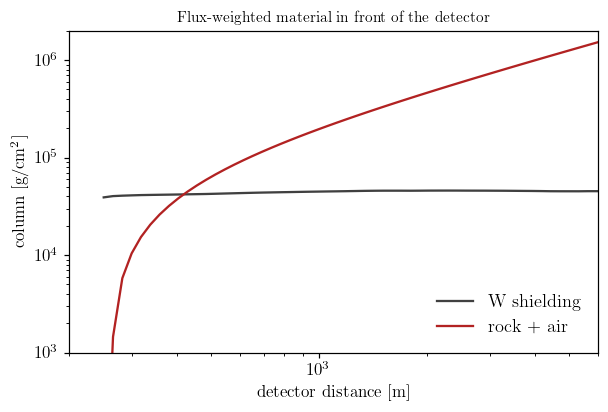

In [55]:
# flux-weighted tungsten column seen by the neutrinos that reach the face
sim = sims["numubar"]
DIST_SCAN = np.geomspace(250e2, 100e5, 101)   # cm
rows = []

for D in DIST_SCAN:
    p = bl.flux_weighted_profile(sim, dist=D, exposure=ipy, sign=+1)
    L = p["z1"] - p["z0"]
    isW = np.array(["shield" in n for n in p["names"]])
    rows.append(dict(D=D, colW=float((p["n_nuc"]*L)[isW].sum()),
                     colB=float((p["n_nuc"]*L)[~isW].sum()),
                     XW=float((p["rho"]*L)[isW].sum()),
                     XB=float((p["rho"]*L)[~isW].sum()), flux=p["flux"]))
print(f"{'D [m]':>8} {'W column':>12} {'bulk column':>12} {'W frac':>8} "
      f"{'X_W':>11} {'X_bulk':>11}")

for r_ in rows:
    tot = r_['colW'] + r_['colB']
    print(f"{r_['D']/100:8.0f} {r_['colW']:12.4e} {r_['colB']:12.4e} "
          f"{r_['colW']/tot:8.2%} {r_['XW']:11.4e} {r_['XB']:11.4e}")

fig, ax = plt.subplots(figsize=(6.2, 3.8))

Ds = np.array([r_["D"] for r_ in rows])/100

ax.plot(Ds, [r_["XW"] for r_ in rows], color="0.25", label="W shielding")
ax.plot(Ds, [r_["XB"] for r_ in rows], color="firebrick", label="rock + air")

ax.set_xscale("log") 
ax.set_yscale("log")
ax.set_xlim(200, 6e3)
ax.set_ylim(1e3, 2e6)

ax.set_xlabel("detector distance [m]"); ax.set_ylabel(r"column [g/cm$^2$]")
ax.set_title("Flux-weighted material in front of the detector", fontsize=10)
ax.legend(frameon=False, loc='lower right', fontsize=12)

fig.savefig("plots/beamline_columns.pdf", bbox_inches="tight", dpi=300)

## 10. Neutrino interaction rate vs detector location

In [ ]:
SIGN = {fl: (+1 if fl in mint.beams.MU_PLUS_FLAVORS else -1) for fl in sims}
print("detector side per flavor (mu+ beam -> +z, mu- beam -> -z):", SIGN)

def interactions_at(D, sim, nuflavor, sign=+1):
    # total CC+NC interactions/yr in the detector at D
    origin, direction = dt.sim_rays(sim)
    if sign < 0:
        origin = (origin[0], origin[1], -origin[2])
        direction = (direction[0], direction[1], -direction[2])
    gas_vol = dt.CylinderVolume(det.gas, radius=DET_R, length=DET_L,
                                center=(0, 0, D + DET_L/2))
    _, ch = gas_vol.intersect(origin, direction)
    column = det.gas.N * ch
    for z0, thick, mat in det.targets:
        slab = dt.CylinderVolume(mat, radius=DET_R, length=thick,
                                 center=(0, 0, D + z0 + thick/2))
        _, chs = slab.intersect(origin, direction)
        column = column + mat.N * chs
    E = np.asarray(sim.pnu["E"]); w = sim.weights.flatten() * ipy
    m = (column > 0) & (E > 5.0)
    sig = np.clip(xsecs.total_xsecs[nuflavor](E[m]), 0.0, None)
    return float(np.sum(w[m] * -np.expm1(-sig * column[m])))

face_flux = {}
for fl, s_ in sims.items():
    face_flux[fl] = np.array([det.face_flux(s_, exposure=ipy, dist=D,
                                            sign=SIGN[fl])[1].sum()
                              for D in DIST_SCAN])
ff = sum(face_flux.values())
print("flux through the face [nu/yr]:")
for i, D in enumerate(DIST_SCAN):
    print(f"  {D/100:8.0f} m  {ff[i]:.4e}   (relative to 250 m: {ff[i]/ff[0]:.3f})")

scan = {}
for fl, s in sims.items():
    scan[fl] = np.array([interactions_at(D, s, fl, sign=SIGN[fl]) for D in DIST_SCAN])
tot = sum(scan.values())
print(f"{'D [m]':>8} " + " ".join(f"{fl:>12}" for fl in scan) + f" {'TOTAL':>12}")
for i, D in enumerate(DIST_SCAN):
    print(f"{D/100:8.0f} " + " ".join(f"{scan[fl][i]:12.4e}" for fl in scan)
          + f" {tot[i]:12.4e}")

detector side per flavor (mu+ beam -> +z, mu- beam -> -z): {'numubar': 1, 'nue': 1, 'numu': -1, 'nuebar': -1}
flux through the face [nu/yr]:
       250 m  7.0030e+18   (relative to 250 m: 1.000)
       265 m  7.0194e+18   (relative to 250 m: 1.002)
       282 m  7.0349e+18   (relative to 250 m: 1.005)
       299 m  7.0524e+18   (relative to 250 m: 1.007)
       318 m  7.0676e+18   (relative to 250 m: 1.009)
       337 m  7.0828e+18   (relative to 250 m: 1.011)
       358 m  7.0966e+18   (relative to 250 m: 1.013)
       380 m  7.1100e+18   (relative to 250 m: 1.015)
       404 m  7.1203e+18   (relative to 250 m: 1.017)
       429 m  7.1283e+18   (relative to 250 m: 1.018)
       455 m  7.1351e+18   (relative to 250 m: 1.019)
       483 m  7.1443e+18   (relative to 250 m: 1.020)
       513 m  7.1517e+18   (relative to 250 m: 1.021)
       545 m  7.1561e+18   (relative to 250 m: 1.022)
       578 m  7.1585e+18   (relative to 250 m: 1.022)
       614 m  7.1595e+18   (relative to 250 m: 1.

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_75014/2700719086.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


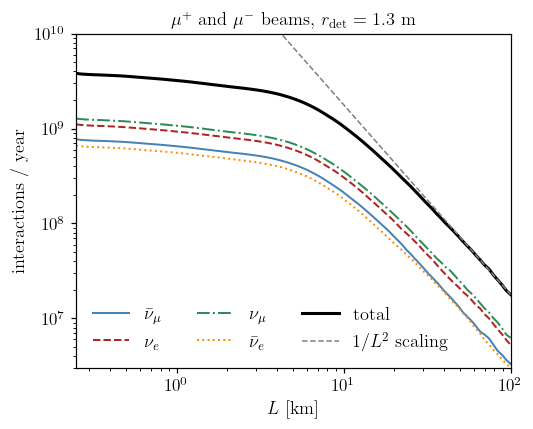

In [75]:
fig, ax = mint.plot_tools.std_fig(figsize=(5, 4))
cols = {"numubar": "steelblue", "nue": "firebrick",
        "numu": "seagreen", "nuebar": "darkorange"}
ls = {"numubar": "-", "nue": "--",
        "numu": "-.", "nuebar": ":"}
labels = {"numubar": r"$\bar{\nu}_\mu$", "nue": r"$\nu_e$",
          "numu": r"$\nu_\mu$", "nuebar": r"$\bar{\nu}_e$"}
for fl in scan:
    ax.plot(DIST_SCAN/1e5, scan[fl], lw=1.3, color=cols.get(fl, "k"), ls=ls.get(fl, "-"), label=labels.get(fl, fl))
ax.plot(DIST_SCAN/1e5, tot, "k-", lw=2.0, label="total")
ax.plot(DIST_SCAN/1e5, tot[-1]/(DIST_SCAN/DIST_SCAN[-1])**2, ls='--', lw=1.0, color='grey', label="$1/L^2$ scaling")

ax.set_ylim(3e6, 1e10)
ax.set_xlim(DIST_SCAN[0]/1e5, DIST_SCAN[-1]/1e5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$L$ [km]", fontsize=12)
ax.set_ylabel(r"interactions / year", fontsize=12)
ax.set_title(r"$\mu^+$ and $\mu^-$ beams, $r_{\rm det} = 1.3$ m", fontsize=12)
ax.legend(frameon=False, fontsize=12, ncol=3)
plt.tight_layout()
fig.savefig("plots/beamline_nu_rate_vs_distance.pdf", bbox_inches="tight", dpi=300)

## 11. Secondary muon flux vs detector location

Muons from $\nu$ CC interactions upstream, now produced anywhere in the
material profile: the tungsten shielding, the tunnel air and the rock. At
250 m there is **no rock at all** -- every secondary muon comes from the
machine shielding.

First a regression check: with the face at 5 km, where the profile is
overwhelmingly rock, the new profile-aware MC must reproduce the original
rock-only calculation.

In [19]:
import muon_beam as mb

def muon_flux_at(D, sim, nuflavor, n_mc=40_000, seed=7, sign=+1):
    E, w, rx, ry, sx, sy = det.face_rays(sim, exposure=ipy, dist=D, E_min=5.0,
                                         sign=sign)
    if E.size == 0:
        return None
    p = bl.flux_weighted_profile(sim, dist=D, exposure=ipy, E_min=5.0, sign=sign)
    out = mb.muon_beam_profile_mc(E, w, rx, ry, sx, sy, nuflavor,
                                  np.random.default_rng(seed), p, dist=D,
                                  det_r=DET_R, n_mc=n_mc)
    acc = np.hypot(out["srv_x"], out["srv_y"]) < DET_R
    return dict(rate=float(out["srv_w"][acc].sum()),
                E=out["srv_E"][acc], w=out["srv_w"][acc],
                z=out["srv_z"][acc] if "srv_z" in out else None)

# --- regression: profile-aware vs the original rock-only MC at 5 km ---
E5, w5, rx5, ry5, sx5, sy5 = det.face_rays(sims["numubar"], exposure=ipy,
                                           dist=5e5, E_min=5.0)
old = mb.muon_beam_mc(E5, w5, rx5, ry5, sx5, sy5, "numubar",
                      np.random.default_rng(7), l_prop_cm=2.5e5, gap_cm=GAP,
                      det_r=DET_R, n_mc=40_000)
acc_o = np.hypot(old["srv_x"], old["srv_y"]) < DET_R
new = muon_flux_at(5e5, sims["numubar"], "numubar", n_mc=40_000)
print(f"5 km, numubar:  rock-only MC = {old['srv_w'][acc_o].sum():.4e} mu/yr")
print(f"                profile   MC = {new['rate']:.4e} mu/yr")
print(f"                ratio         = {new['rate']/old['srv_w'][acc_o].sum():.4f}")

5 km, numubar:  rock-only MC = 5.9426e+11 mu/yr
                profile   MC = 5.9061e+11 mu/yr
                ratio         = 0.9938


In [20]:
mu_scan = {}
for fl in ("numubar", "numu"):
    mu_scan[fl] = []
    for D in DIST_SCAN:
        r_ = muon_flux_at(D, sims[fl], fl, sign=SIGN[fl])
        mu_scan[fl].append(r_["rate"] if r_ else 0.0)
    mu_scan[fl] = np.array(mu_scan[fl])
mu_tot = sum(mu_scan.values())
print(f"{'D [m]':>8} {'numubar':>13} {'numu':>13} {'total':>13} {'per cm2/yr':>13}")
for i, D in enumerate(DIST_SCAN):
    print(f"{D/100:8.0f} {mu_scan['numubar'][i]:13.4e} {mu_scan['numu'][i]:13.4e} "
          f"{mu_tot[i]:13.4e} {mu_tot[i]/(np.pi*DET_R**2):13.4e}")

   D [m]       numubar          numu         total    per cm2/yr
     250    2.1423e+11    2.6161e+11    4.7584e+11    9.2794e+06
     328    3.0056e+11    3.8136e+11    6.8193e+11    1.3298e+07
     431    3.9878e+11    5.0554e+11    9.0432e+11    1.7635e+07
     566    4.9180e+11    5.9580e+11    1.0876e+12    2.1209e+07
     743    5.5683e+11    6.6743e+11    1.2243e+12    2.3874e+07
     976    6.0778e+11    7.1451e+11    1.3223e+12    2.5786e+07
    1281    6.4307e+11    7.3169e+11    1.3748e+12    2.6809e+07
    1682    6.6121e+11    7.4314e+11    1.4044e+12    2.7386e+07
    2209    6.4249e+11    7.6545e+11    1.4079e+12    2.7456e+07
    2900    6.3356e+11    7.5349e+11    1.3870e+12    2.7049e+07
    3808    6.2171e+11    7.1982e+11    1.3415e+12    2.6161e+07
    5000    5.8956e+11    6.8558e+11    1.2751e+12    2.4866e+07


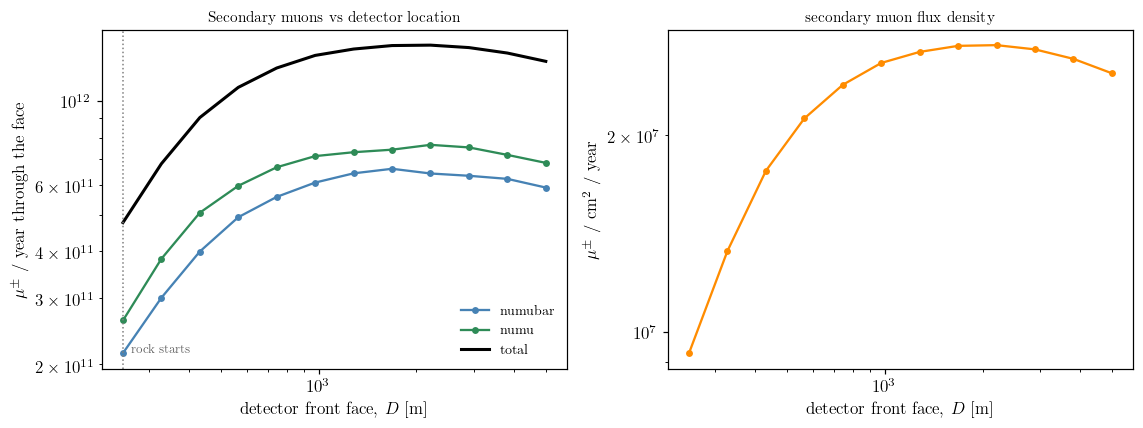

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.0))
for fl, c in (("numubar", "steelblue"), ("numu", "seagreen")):
    ax[0].plot(DIST_SCAN/100, mu_scan[fl], "o-", ms=3.5, color=c, label=fl)
ax[0].plot(DIST_SCAN/100, mu_tot, "k-", lw=2, label="total")
ax[0].axvline(det.rock_start/100, color="0.5", ls=":", lw=1)
ax[0].annotate("rock starts", xy=(det.rock_start/100*1.06, 0.05),
               xycoords=("data", "axes fraction"), fontsize=8, color="0.4")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("detector front face, $D$ [m]")
ax[0].set_ylabel(r"$\mu^\pm$ / year through the face")
ax[0].set_title("Secondary muons vs detector location", fontsize=10)
ax[0].legend(frameon=False, fontsize=9)

ax[1].plot(DIST_SCAN/100, mu_tot/(np.pi*DET_R**2), "o-", color="darkorange", ms=3.5)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("detector front face, $D$ [m]")
ax[1].set_ylabel(r"$\mu^\pm$ / cm$^2$ / year")
ax[1].set_title("secondary muon flux density", fontsize=10)
plt.tight_layout()
fig.savefig("plots/beamline_muon_vs_distance.pdf", bbox_inches="tight", dpi=300)

## 12. Secondary $\nu_\tau$ rate vs detector location

Charmed-meson chains ($D_s^\pm, D^\pm \to \tau\nu_\tau$, then $\tau \to \nu_\tau$)
produced by $\nu$ CC interactions in the same material profile. The production
rate is linear in the target column, so the flux-weighted profile gives it
exactly; the geometric acceptance $\theta \times L_{\rm rem} < R_{\rm det}$
depends on where along the profile the chain starts.

In [22]:
import nutau_secondary as nts

def nutau_at(D, sim, nuflavor, n_mc=200_000, seed=11, sign=+1):
    E, w, *_ = det.face_rays(sim, exposure=ipy, dist=D, E_min=20.0, sign=sign)
    if E.size == 0:
        return 0.0
    Ec, Wc = dt.bin_flux(E, w, n_bins=60, E_min=20.0)
    p = bl.flux_weighted_profile(sim, dist=D, exposure=ipy, E_min=20.0, sign=sign)
    L = p["z1"] - p["z0"]
    col = float((p["n_nuc"] * L).sum())        # nucleons/cm^2 along the sightline
    rng_ = np.random.default_rng(seed)
    chains = (col * (nts.F_DS*nts.BR_DS_TAUNU + nts.F_DPM*nts.BR_DPM_TAUNU)
              * float(np.sum(Wc * nts.sigma_charm_cc(Ec, nuflavor))))
    E1, th1, E2, th2 = nts.sample_nutau_chains(n_mc, Ec, Wc, nuflavor, rng=rng_)
    # production point sampled from the profile (proportional to n_nuc dz)
    z, _, _ = bl.sample_vertices({"z0": p["z0"], "z1": p["z1"],
                                  "n_nuc": np.tile(p["n_nuc"], (n_mc, 1))}, rng_)
    L_rem = np.clip(D - z, 1.0, None)
    acc = ((th1 * L_rem < DET_R).sum() + (th2 * L_rem < DET_R).sum()) / n_mc
    return chains * acc

nt_scan = np.array([nutau_at(D, sims["numubar"], "numubar", sign=SIGN["numubar"]) for D in DIST_SCAN])
nt_scan_p = np.array([nutau_at(D, sims["numu"], "numu", sign=SIGN["numu"]) for D in DIST_SCAN])
print(f"{'D [m]':>8} {'nutau (mu- beam)':>18} {'nutau (mu+ beam)':>18} {'total':>14}")
for i, D in enumerate(DIST_SCAN):
    print(f"{D/100:8.0f} {nt_scan[i]:18.4e} {nt_scan_p[i]:18.4e} "
          f"{nt_scan[i]+nt_scan_p[i]:14.4e}")

   D [m]   nutau (mu- beam)   nutau (mu+ beam)          total
     250         2.3615e+08         3.0591e+08     5.4206e+08
     328         3.4296e+08         4.4468e+08     7.8764e+08
     431         4.5588e+08         5.8794e+08     1.0438e+09
     566         5.4511e+08         7.0004e+08     1.2452e+09
     743         6.1346e+08         7.8814e+08     1.4016e+09
     976         6.6335e+08         8.5490e+08     1.5183e+09
    1281         7.0109e+08         9.0577e+08     1.6069e+09
    1682         7.3070e+08         9.3981e+08     1.6705e+09
    2209         7.5132e+08         9.7005e+08     1.7214e+09
    2900         7.6526e+08         9.8400e+08     1.7493e+09
    3808         7.8088e+08         1.0030e+09     1.7839e+09
    5000         7.8457e+08         1.0036e+09     1.7882e+09


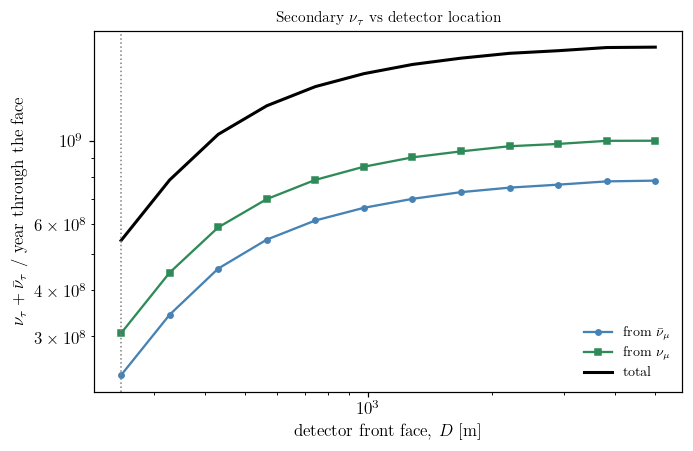

In [23]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(DIST_SCAN/100, nt_scan, "o-", ms=3.5, color="steelblue",
        label=r"from $\bar\nu_\mu$")
ax.plot(DIST_SCAN/100, nt_scan_p, "s-", ms=3.5, color="seagreen",
        label=r"from $\nu_\mu$")
ax.plot(DIST_SCAN/100, nt_scan + nt_scan_p, "k-", lw=2, label="total")
ax.axvline(det.rock_start/100, color="0.5", ls=":", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("detector front face, $D$ [m]")
ax.set_ylabel(r"$\nu_\tau + \bar\nu_\tau$ / year through the face")
ax.set_title("Secondary $\\nu_\\tau$ vs detector location", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
fig.savefig("plots/beamline_nutau_vs_distance.pdf", bbox_inches="tight", dpi=300)

## 13. Notes and open assumptions

- **Drift-section wall thickness.** MuCol Milestone 15 states that the drift
  beam pipe is surrounded by tungsten but gives no thickness; the quadrupole
  value of 2.53 cm is used. Sec. 3 shows the linear sensitivity.
- **Minimum aperture.** The $5\sigma$ envelope collapses to microns at the
  waists in the long straight, so a 2 cm floor is assumed. This is the single
  most important assumption for the secondary rates: it sets *which* emission
  angles graze along the tungsten wall (Sec. 3).
- **Not modelled**: magnet coils, supports, cold bore, insulation (thin and
  light next to the tungsten), and the detector nozzle inside $|z| < L^* = 6$ m
  (upstream of everything the forward flux traverses).
- The shielding is a **thin tube**, so its contribution is strongly
  ray-dependent. `ray_profile` keeps that per-ray; `flux_weighted_profile`
  averages it, which is exact for rates linear in the column (all production
  rates) but not for the angular distribution of the secondaries.